In [1]:
import pandas as pd
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()

You shall already be familiar with the concept of association rules and the apriori algorithm. Association rule mining is a method for discovering patterns within large data sets. It focuses on identifying relationships between variables and leveraging those connections to make predictions or informed decisions. The primary objective is to uncover rules that reveal the associations between various items in the data.



### Task
Load data from data.txt file - it contains lists of grocery shopping done by nearly 2000 customers.
Store it in a boolean one hot encoded dataframe - True for items bought in a given transaction, False otherwise.

In [2]:
from mlxtend.preprocessing import TransactionEncoder

with open("data.txt", "r") as file:
    transactions = [eval(line.strip()) for line in file]

encoder = TransactionEncoder()
data = encoder.fit_transform(transactions)
df = pd.DataFrame(data, columns=encoder.columns_)
df

,apple,banana,beef,bread,butter,cheese,chicken,chocolate,eggs,grill,ketchup,milk,mustard,orange,pork,sausage,wagyu,yogurt
0,True,True,False,False,False,False,True,True,False,False,False,True,False,True,False,False,False,False
1,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,True
2,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False
4,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1911,False,False,False,True,False,False,False,True,True,False,False,True,False,False,False,False,False,False
1912,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False
1913,True,False,False,True,False,False,False,False,False,False,False,True,False,False,True,False,False,False
1914,False,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False


To extract rules you can use e.g. apriori algorithm implemented in mlxtend. There are other algorithms performing the same task but using different approaches e.g. fpgrowth internally uses a tree-based structure which makes it faster in most real-life examples.

### Task
Find association rules using selected algorithm

In [3]:

# sample parameters
min_support = 0.1
min_confidence = 0.6

frequent_itemsets = apriori(df, min_support=min_support, use_colnames=True)
rules = association_rules(frequent_itemsets, df.shape[0], metric="confidence", min_threshold=min_confidence)
rules

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(chocolate),(milk),0.179541,0.400313,0.122651,0.683140,1.706513,1.0,0.050779,1.892590,0.504607,0.268265,0.471623,0.494764
1,(grill),(sausage),0.113257,0.248434,0.105428,0.930876,3.746970,1.0,0.077291,10.872651,0.826753,0.411405,0.908026,0.677623


### Task
The association rules are characterized by high support - frequency in the dataset. Can you use this algorithm as a base and try to extract different types of rules:
 - dissociation rules e.g. buying Porshe and Rolex is not frequent in the dataset, but usually people who bought Porshe also bought Rolex
 - negative rules e.g. if someone bought low-fat milk it's unlikely there will be whole milk in the basket
 - disjunction e.g. eggs and (kielecki xor winiary ;) )
 - imagine 50% of baskets have milk and 50% of baskets have tea. If there is no relation between them then in ~25% of baskets we will have both. If milk appears together with tea in e.g. 40% of baskets it means there is a pattern. Can you find such rules and use statistical tests to check if the relation is strong?

 Send the report within 144 hours starting from the end of this class to gmiebs@cs.put.poznan.pl; start this email's subject with [IR]


### Quick analysis

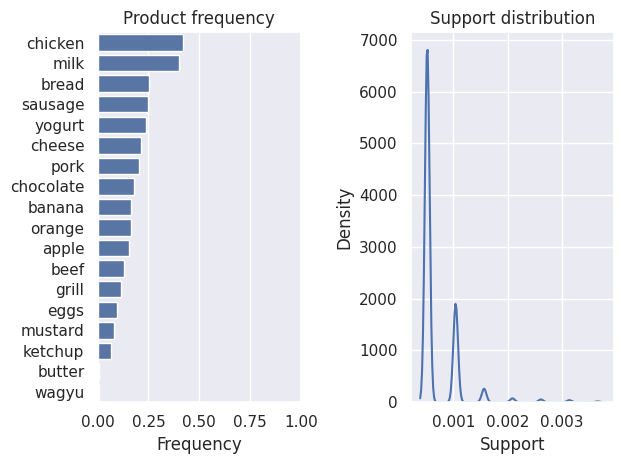

In [4]:

product_frequency = df.mean().sort_values(ascending=False)
fig, axes = plt.subplots(1, 2)

sns.barplot(product_frequency, orient="h", ax=axes[0])
axes[0].set_title("Product frequency")
axes[0].set_xlabel("Frequency")
axes[0].set_xlim(right=1)

min_support = 0.0001
min_confidence = 0.6
percentile = 0.99
frequent_itemsets = apriori(df, min_support=min_support, use_colnames=True)
rules = association_rules(frequent_itemsets, df.shape[0], metric="confidence", min_threshold=min_confidence)
sns.kdeplot(rules["support"][rules["support"] < rules["support"].quantile(percentile)])
axes[1].set_title("Support distribution")
axes[1].set_xlabel("Support")
plt.tight_layout()

### Dissociation rules

The idea is to pick rules with small support but still with high association.

In [222]:
def dissociation(
    df: pd.DataFrame,
    min_support: float,
    max_support: float,
    metric: str,
    min_metric: float
):
    # Fit rules
    temp_df = df
    frequent_itemsets = apriori(temp_df, min_support=min_support, use_colnames=True)
    rules = association_rules(frequent_itemsets, temp_df.shape[0], metric=metric, min_threshold=min_metric)

    # Consider number of antecendents (the less, the more interesting the rule is)
    rules["n_antecedents"] = rules["antecedents"].apply(lambda x: len(x))
    return rules[rules["support"] < max_support].sort_values(["n_antecedents", metric], ascending=[True, False])

In [234]:
dissociation(df, 0.01, 0.02, "confidence", 0.7).head(10)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski,n_antecedents
9,"(grill, apple)",(sausage),0.013570,0.248434,0.013570,1.000000,4.025210,1.0,0.010199,inf,0.761905,0.054622,1.000000,0.527311,2
11,"(banana, grill)",(sausage),0.019833,0.248434,0.018789,0.947368,3.813357,1.0,0.013862,14.279749,0.752692,0.075314,0.929971,0.511499,2
46,"(orange, grill)",(sausage),0.017745,0.248434,0.016180,0.911765,3.670044,1.0,0.011771,8.517745,0.740667,0.064718,0.882598,0.488445,2
13,"(beef, grill)",(sausage),0.011482,0.248434,0.010438,0.909091,3.659282,1.0,0.007586,8.267223,0.735164,0.041841,0.879040,0.475554,2
12,"(banana, ketchup)",(sausage),0.013570,0.248434,0.012004,0.884615,3.560763,1.0,0.008633,6.513570,0.729055,0.048017,0.846474,0.466467,2
25,"(mustard, cheese)",(sausage),0.013570,0.248434,0.012004,0.884615,3.560763,1.0,0.008633,6.513570,0.729055,0.048017,0.846474,0.466467,2
15,"(bread, ketchup)",(grill),0.013048,0.113257,0.011482,0.880000,7.769954,1.0,0.010004,7.389527,0.882818,0.100000,0.864673,0.490691,2
18,"(bread, ketchup)",(sausage),0.013048,0.248434,0.011482,0.880000,3.542185,1.0,0.008241,6.263048,0.727177,0.045929,0.840333,0.463109,2
78,"(bread, ketchup)","(grill, sausage)",0.013048,0.105428,0.011482,0.880000,8.346931,1.0,0.010107,7.454767,0.891832,0.107317,0.865858,0.494455,2
24,"(ketchup, cheese)",(sausage),0.014614,0.248434,0.012526,0.857143,3.450180,1.0,0.008896,5.260960,0.720692,0.050000,0.809921,0.453782,2


Column `sausage` occurs a lot, so let's try to get rid of it:

In [237]:
dissociation(df.drop("sausage", axis=1), 0.01, 0.02, "confidence", 0.7).head(10)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski,n_antecedents
8,"(bread, ketchup)",(grill),0.013048,0.113257,0.011482,0.880000,7.769954,1.0,0.010004,7.389527,0.882818,0.100000,0.864673,0.490691,2
6,"(banana, ketchup)",(grill),0.013570,0.113257,0.011482,0.846154,7.471110,1.0,0.009945,5.763831,0.878066,0.099548,0.826504,0.473768,2
15,"(chocolate, mustard)",(grill),0.015658,0.113257,0.013048,0.833333,7.357911,1.0,0.011275,5.320459,0.877837,0.112613,0.812046,0.474270,2
11,"(ketchup, cheese)",(grill),0.014614,0.113257,0.012004,0.821429,7.252798,1.0,0.010349,4.965762,0.874908,0.103604,0.798621,0.463710,2
20,"(pork, mustard)",(grill),0.014092,0.113257,0.011482,0.814815,7.194402,1.0,0.009886,4.788413,0.873310,0.099099,0.791163,0.458099,2
12,"(mustard, cheese)",(grill),0.013570,0.113257,0.010960,0.807692,7.131514,1.0,0.009423,4.611065,0.871605,0.094595,0.783130,0.452233,2
13,"(chicken, ketchup)",(grill),0.022965,0.113257,0.018267,0.795455,7.023460,1.0,0.015666,4.335189,0.877778,0.154867,0.769330,0.478372,2
5,"(chocolate, apple)",(milk),0.025052,0.400313,0.019833,0.791667,1.977618,1.0,0.009804,2.878497,0.507044,0.048906,0.652596,0.420605,2
18,"(ketchup, yogurt)",(grill),0.016180,0.113257,0.012526,0.774194,6.835737,1.0,0.010694,3.927006,0.867750,0.107143,0.745353,0.442396,2
9,"(bread, mustard)",(grill),0.018267,0.113257,0.013570,0.742857,6.559052,1.0,0.011501,3.448446,0.863309,0.115044,0.710014,0.431336,2


Let's do the same for `grill`:

In [240]:
dissociation(df.drop(["sausage", "grill"], axis=1), 0.01, 0.02, "confidence", 0.7).head(5)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski,n_antecedents
3,"(chocolate, apple)",(milk),0.025052,0.400313,0.019833,0.791667,1.977618,1.0,0.009804,2.878497,0.507044,0.048906,0.652596,0.420605,2
18,"(banana, pork, apple)",(orange),0.012526,0.162317,0.011482,0.916667,5.647374,1.0,0.009449,10.052192,0.833365,0.070288,0.900519,0.493703,3
21,"(banana, yogurt, apple)",(orange),0.015658,0.162317,0.014092,0.900000,5.544695,1.0,0.011550,8.376827,0.832685,0.085987,0.880623,0.493408,3
16,"(orange, banana, pork)",(apple),0.013048,0.151879,0.011482,0.880000,5.794089,1.0,0.009501,7.067676,0.838349,0.074830,0.858511,0.477801,3
20,"(orange, yogurt, apple)",(banana),0.016180,0.165449,0.014092,0.870968,5.264272,1.0,0.011415,6.467771,0.823362,0.084112,0.845387,0.478071,3


Now, it seems more reasonable.

### Negative rules

In [246]:
min_support = 0.01
min_lift = 0.0
frequent_itemsets = apriori(df, min_support=min_support, use_colnames=True)
rules = association_rules(frequent_itemsets, df.shape[0], metric="zhangs_metric", min_threshold=-1)
rules.loc[(rules["lift"] < 1), ["antecedents", "consequents", "lift", "confidence", "zhangs_metric"]].sort_values("zhangs_metric").head(10)

,antecedents,consequents,lift,confidence,zhangs_metric
134,(chicken),(pork),0.151220,0.031017,-0.906442
135,(pork),(chicken),0.151220,0.063613,-0.875950
578,(chicken),"(bread, cheese)",0.760695,0.039702,-0.351919
902,(milk),"(chicken, eggs)",0.761599,0.032595,-0.342963
1141,(orange),"(milk, sausage)",0.699331,0.067524,-0.339169
3,(apple),(beef),0.698731,0.089347,-0.337037
2,(beef),(apple),0.698731,0.106122,-0.330828
1140,"(milk, sausage)",(orange),0.699331,0.113514,-0.322442
763,(chicken),"(milk, cheese)",0.787783,0.070720,-0.317402
1142,(milk),"(orange, sausage)",0.782969,0.027379,-0.316110
